Dataset shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Basic Stats:
        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


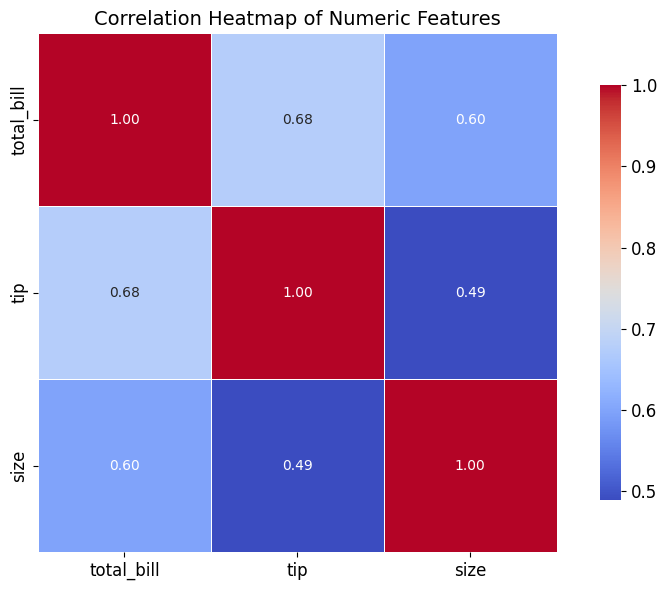

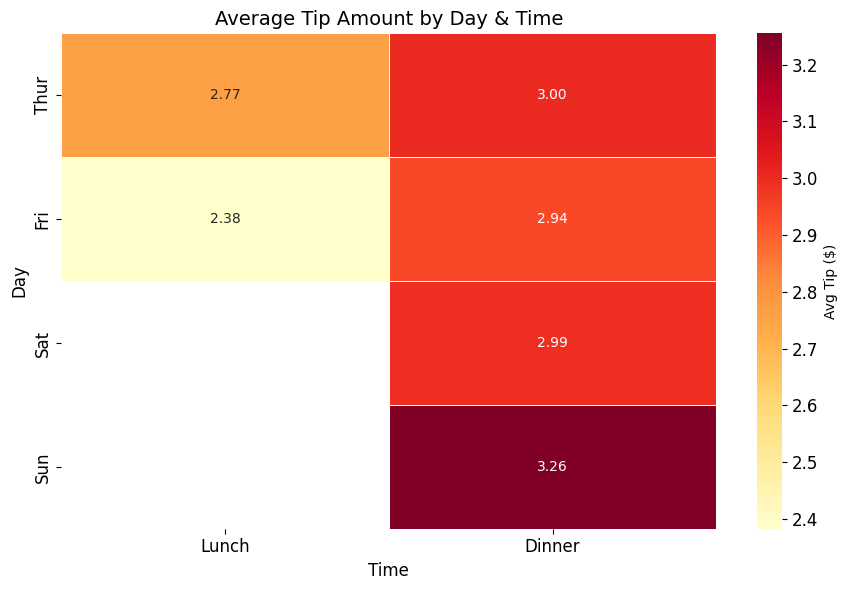

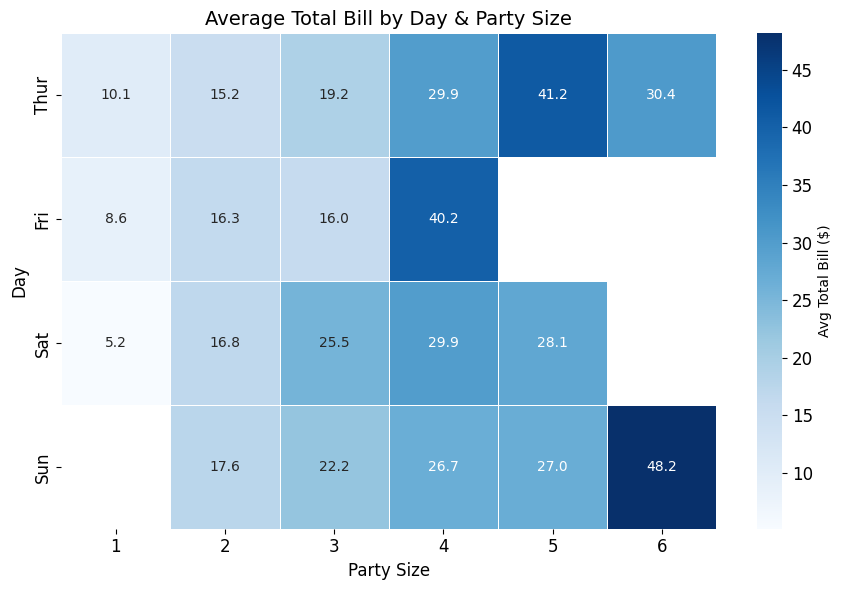

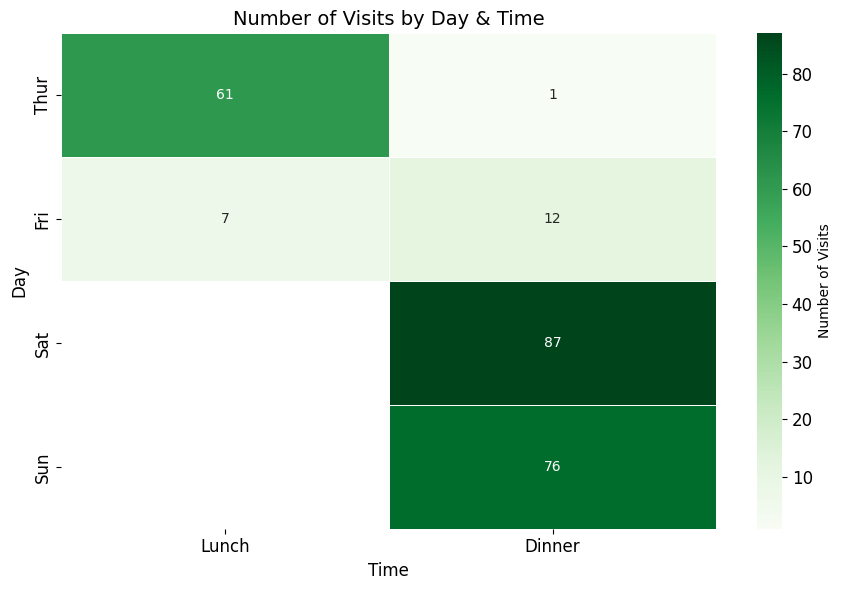

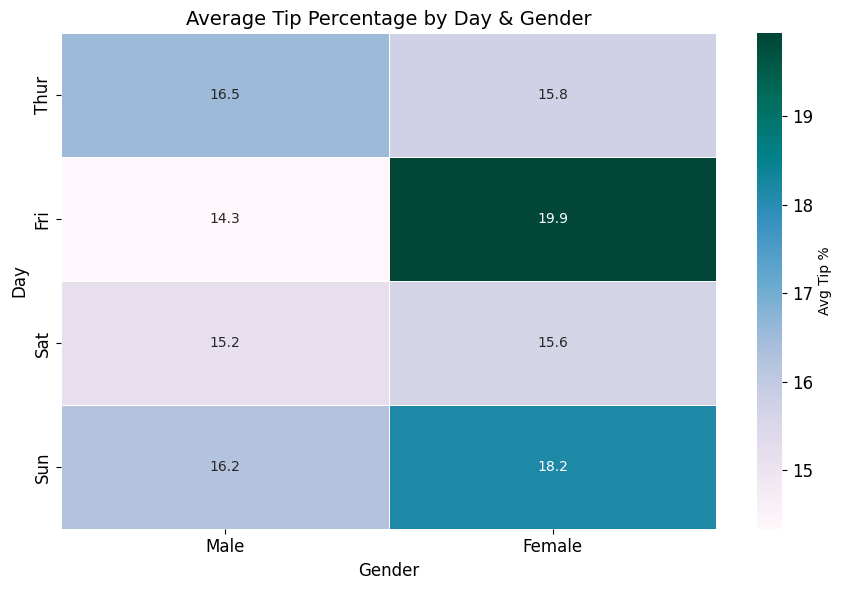

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26864\715561938.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='day', y='tip',


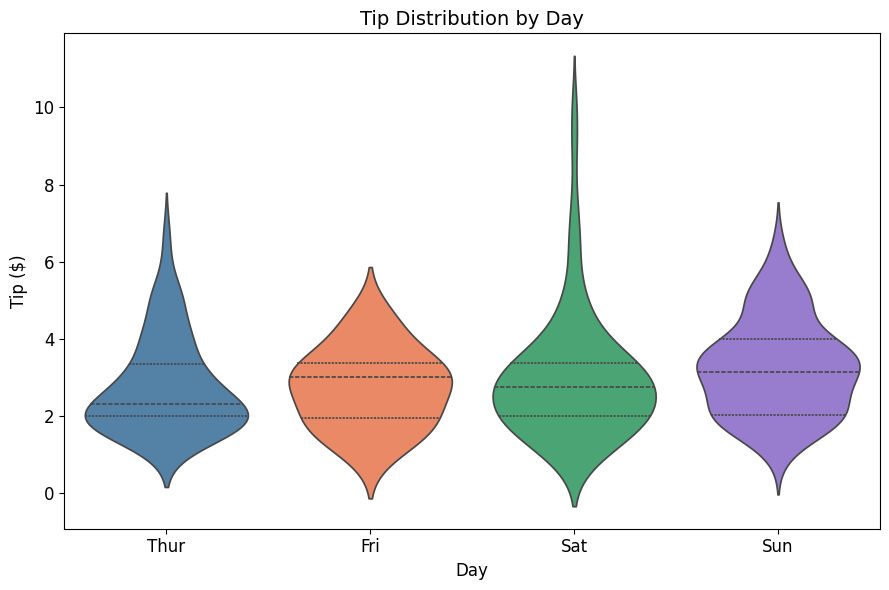

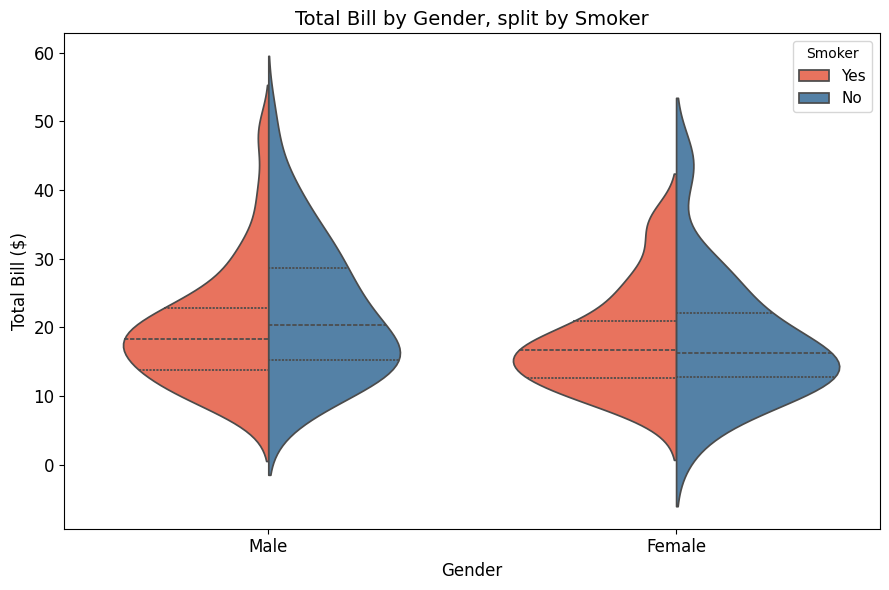

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26864\715561938.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='time', y='tip',


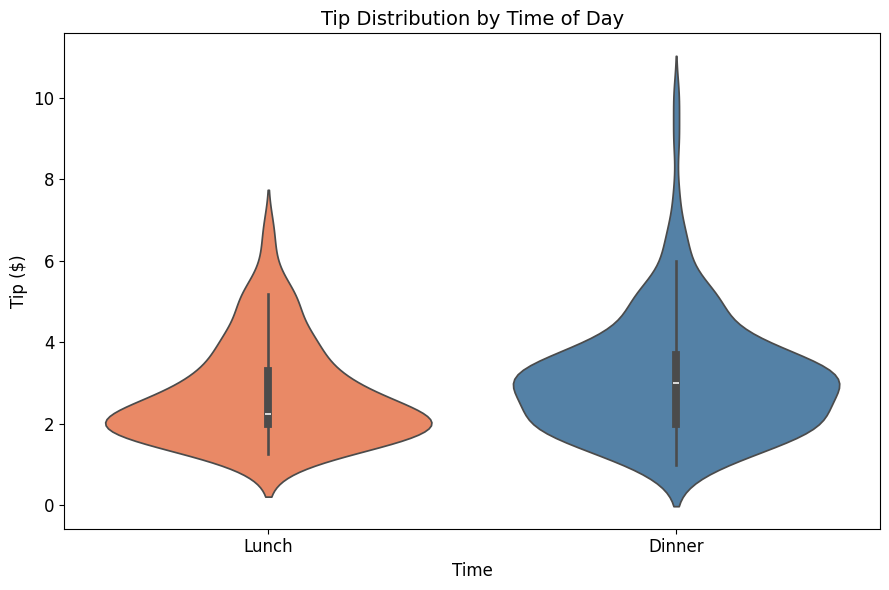

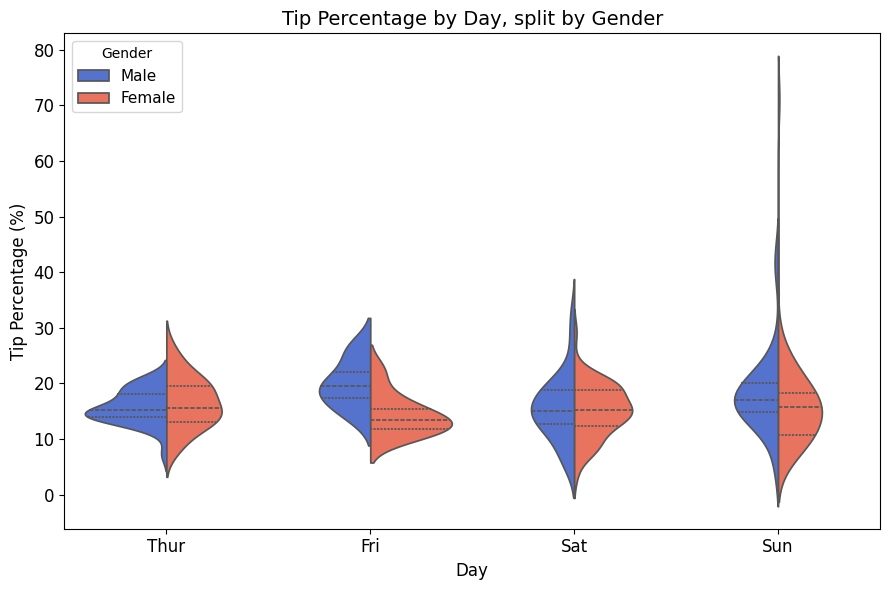

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26864\715561938.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='size', y='total_bill',


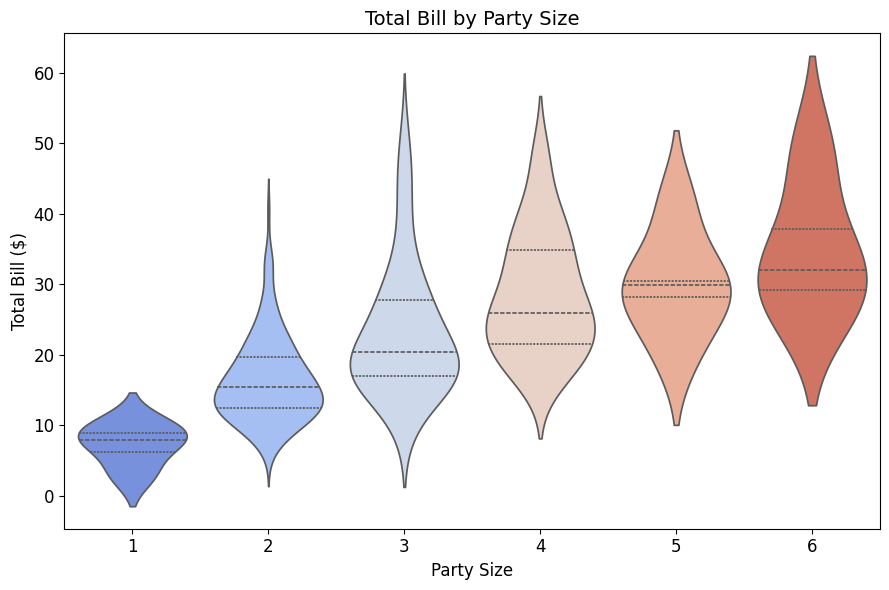

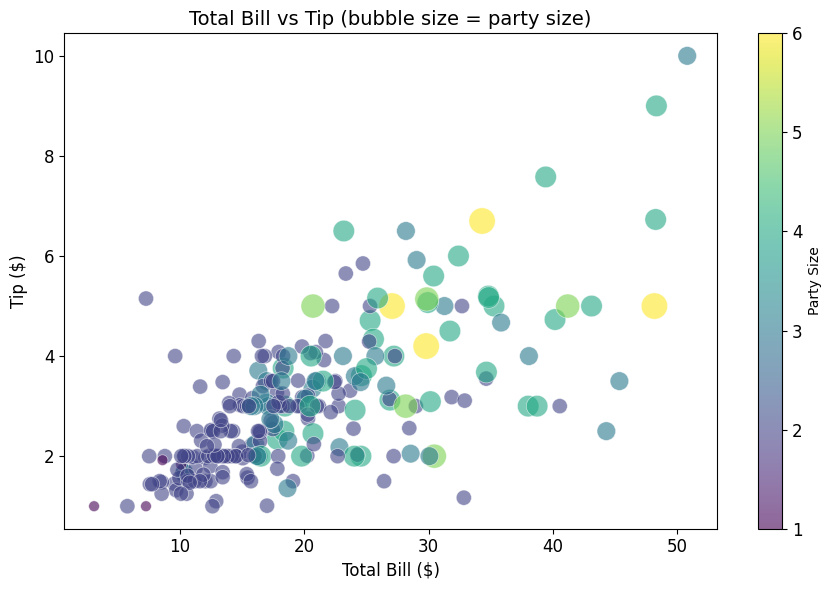

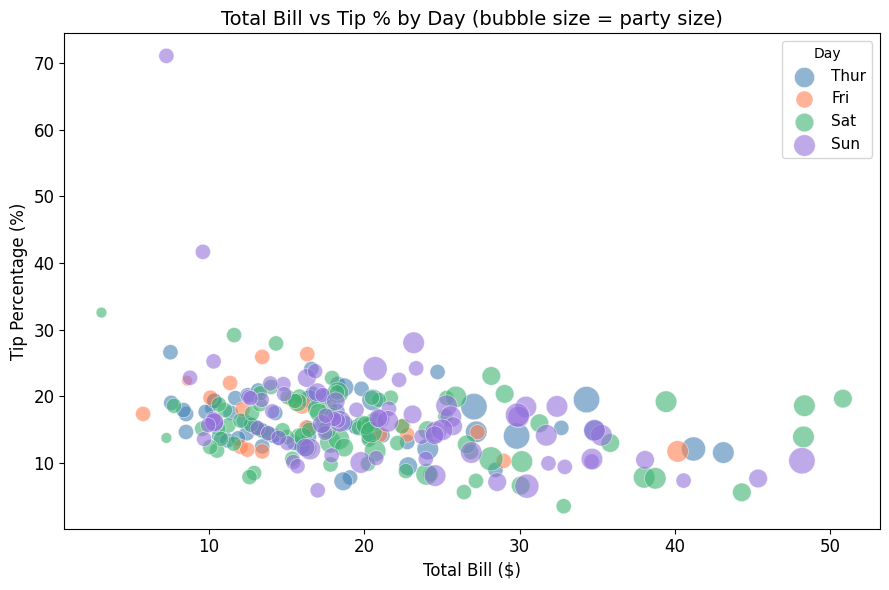

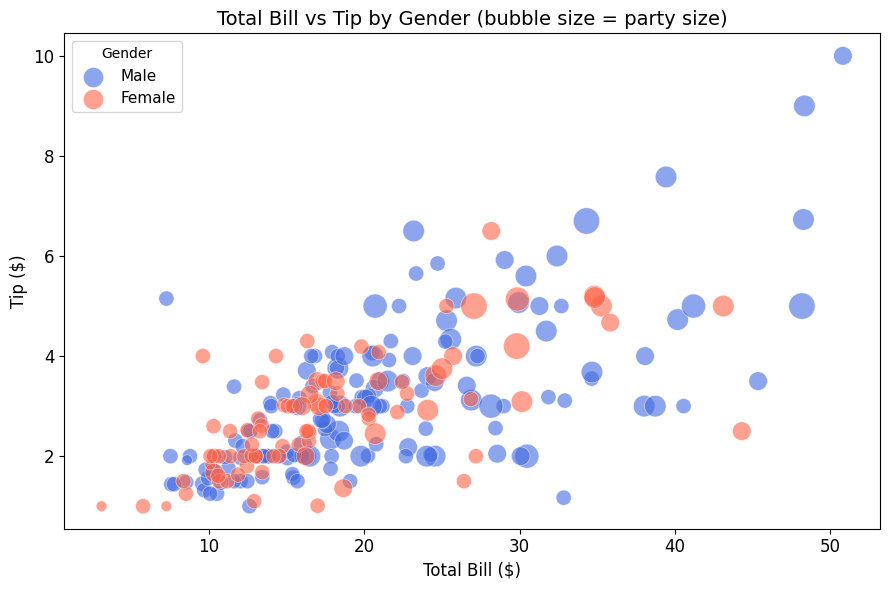

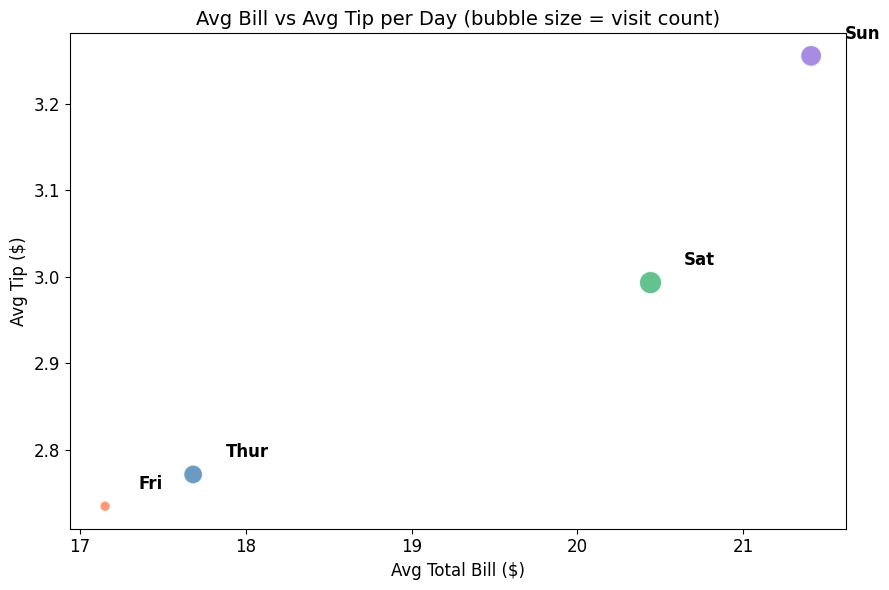

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
%matplotlib inline
 
# ── Load Dataset ───────────────────────────────────────────────────────────────
tips = sns.load_dataset('tips')
 
print("Dataset shape:", tips.shape)
print(tips.head())
print("\nColumns:", tips.columns.tolist())
print("\nBasic Stats:\n", tips.describe())
 
# ── Global Style ───────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (9, 6)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
 
 
# ══════════════════════════════════════════════════════════════════════════════
# HEATMAPS
# ══════════════════════════════════════════════════════════════════════════════
 
# ── 1. Correlation Heatmap ─────────────────────────────────────────────────────
plt.figure()
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
corr = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.tight_layout()
plt.show()
 
 
# ── 2. Heatmap: Average Tip by Day and Time ────────────────────────────────────
plt.figure()
plt.title("Average Tip Amount by Day & Time", fontsize=14)
pivot = tips.pivot_table(values='tip', index='day', columns='time', aggfunc='mean')
sns.heatmap(pivot,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Avg Tip ($)'})
plt.xlabel("Time", fontsize=12)
plt.ylabel("Day", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 3. Heatmap: Average Total Bill by Day and Party Size ──────────────────────
plt.figure()
plt.title("Average Total Bill by Day & Party Size", fontsize=14)
pivot2 = tips.pivot_table(values='total_bill', index='day',
                           columns='size', aggfunc='mean')
sns.heatmap(pivot2,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            cbar_kws={'label': 'Avg Total Bill ($)'})
plt.xlabel("Party Size", fontsize=12)
plt.ylabel("Day", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 4. Heatmap: Number of Visits by Day and Time ──────────────────────────────
plt.figure()
plt.title("Number of Visits by Day & Time", fontsize=14)
pivot3 = tips.pivot_table(values='tip', index='day',
                           columns='time', aggfunc='count')
sns.heatmap(pivot3,
            annot=True,
            fmt='.0f',
            cmap='Greens',
            linewidths=0.5,
            cbar_kws={'label': 'Number of Visits'})
plt.xlabel("Time", fontsize=12)
plt.ylabel("Day", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 5. Heatmap: Tip Percentage by Day and Gender ──────────────────────────────
tips['tip_pct'] = (tips['tip'] / tips['total_bill']) * 100
 
plt.figure()
plt.title("Average Tip Percentage by Day & Gender", fontsize=14)
pivot4 = tips.pivot_table(values='tip_pct', index='day',
                           columns='sex', aggfunc='mean')
sns.heatmap(pivot4,
            annot=True,
            fmt='.1f',
            cmap='PuBuGn',
            linewidths=0.5,
            cbar_kws={'label': 'Avg Tip %'})
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Day", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ══════════════════════════════════════════════════════════════════════════════
# VIOLIN PLOTS
# ══════════════════════════════════════════════════════════════════════════════
 
# ── 6. Violin: Tip Distribution by Day ────────────────────────────────────────
plt.figure()
plt.title("Tip Distribution by Day", fontsize=14)
sns.violinplot(data=tips, x='day', y='tip',
               palette=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'],
               inner='quartile')
plt.xlabel("Day", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 7. Violin: Total Bill by Gender (split by Smoker) ─────────────────────────
plt.figure()
plt.title("Total Bill by Gender, split by Smoker", fontsize=14)
sns.violinplot(data=tips, x='sex', y='total_bill',
               hue='smoker', split=True,
               palette={'Yes': 'tomato', 'No': 'steelblue'},
               inner='quartile')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Total Bill ($)", fontsize=12)
plt.legend(title='Smoker', fontsize=11)
plt.tight_layout()
plt.show()
 
 
# ── 8. Violin: Tip by Time of Day ─────────────────────────────────────────────
plt.figure()
plt.title("Tip Distribution by Time of Day", fontsize=14)
sns.violinplot(data=tips, x='time', y='tip',
               palette={'Lunch': 'coral', 'Dinner': 'steelblue'},
               inner='box')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 9. Violin: Tip Percentage by Day (split by Gender) ────────────────────────
plt.figure()
plt.title("Tip Percentage by Day, split by Gender", fontsize=14)
sns.violinplot(data=tips, x='day', y='tip_pct',
               hue='sex', split=True,
               palette={'Male': 'royalblue', 'Female': 'tomato'},
               inner='quartile')
plt.xlabel("Day", fontsize=12)
plt.ylabel("Tip Percentage (%)", fontsize=12)
plt.legend(title='Gender', fontsize=11)
plt.tight_layout()
plt.show()
 
 
# ── 10. Violin: Total Bill by Party Size ──────────────────────────────────────
plt.figure()
plt.title("Total Bill by Party Size", fontsize=14)
sns.violinplot(data=tips, x='size', y='total_bill',
               palette='coolwarm', inner='quartile')
plt.xlabel("Party Size", fontsize=12)
plt.ylabel("Total Bill ($)", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ══════════════════════════════════════════════════════════════════════════════
# BUBBLE CHARTS
# ══════════════════════════════════════════════════════════════════════════════
 
# ── 11. Bubble: Total Bill vs Tip (size = party size) ─────────────────────────
plt.figure()
plt.title("Total Bill vs Tip (bubble size = party size)", fontsize=14)
scatter = plt.scatter(tips['total_bill'], tips['tip'],
                      s=tips['size'] * 60,
                      c=tips['size'],
                      cmap='viridis',
                      alpha=0.6,
                      edgecolors='white',
                      linewidths=0.5)
plt.colorbar(scatter, label='Party Size')
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.tight_layout()
plt.show()
 
 
# ── 12. Bubble: Total Bill vs Tip % (colored by Day) ──────────────────────────
day_colors = {'Thur': 'steelblue', 'Fri': 'coral',
              'Sat': 'mediumseagreen', 'Sun': 'mediumpurple'}
 
plt.figure()
plt.title("Total Bill vs Tip % by Day (bubble size = party size)", fontsize=14)
for day, color in day_colors.items():
    subset = tips[tips['day'] == day]
    plt.scatter(subset['total_bill'], subset['tip_pct'],
                s=subset['size'] * 60,
                color=color,
                alpha=0.6,
                label=day,
                edgecolors='white',
                linewidths=0.5)
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip Percentage (%)", fontsize=12)
plt.legend(title='Day', fontsize=11)
plt.tight_layout()
plt.show()
 
 
# ── 13. Bubble: Total Bill vs Tip (colored by Gender) ─────────────────────────
gender_colors = {'Male': 'royalblue', 'Female': 'tomato'}
 
plt.figure()
plt.title("Total Bill vs Tip by Gender (bubble size = party size)", fontsize=14)
for gender, color in gender_colors.items():
    subset = tips[tips['sex'] == gender]
    plt.scatter(subset['total_bill'], subset['tip'],
                s=subset['size'] * 60,
                color=color,
                alpha=0.6,
                label=gender,
                edgecolors='white',
                linewidths=0.5)
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)
plt.legend(title='Gender', fontsize=11)
plt.tight_layout()
plt.show()
 
 
# ── 14. Bubble: Avg Bill vs Avg Tip per Day (aggregated bubble) ───────────────
agg = tips.groupby('day').agg(
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    count=('tip', 'count')
).reset_index()
 
plt.figure()
plt.title("Avg Bill vs Avg Tip per Day (bubble size = visit count)", fontsize=14)
scatter = plt.scatter(agg['avg_bill'], agg['avg_tip'],
                      s=agg['count'] * 3,
                      c=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'],
                      alpha=0.8,
                      edgecolors='white',
                      linewidths=1)
for _, row in agg.iterrows():
    plt.text(row['avg_bill'] + 0.2, row['avg_tip'] + 0.02,
             row['day'], fontsize=12, fontweight='bold')
plt.xlabel("Avg Total Bill ($)", fontsize=12)
plt.ylabel("Avg Tip ($)", fontsize=12)
plt.tight_layout()
plt.show()